In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

In [23]:
df = pd.read_csv('fifa21_raw_data_v2.csv')
print(f"Shape: {df.shape}")
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('↓', '')

print(df.head(5))
print(df.info())
print(df.describe())

/tmp/ipython-input-672115366.py:1: DtypeWarning:

Columns (76) have mixed types. Specify dtype option on import or set low_memory=False.



Shape: (18979, 77)
       id               name                      longname  \
0  158023           L. Messi                  Lionel Messi   
1   20801  Cristiano Ronaldo  C. Ronaldo dos Santos Aveiro   
2  200389           J. Oblak                     Jan Oblak   
3  192985       K. De Bruyne               Kevin De Bruyne   
4  190871          Neymar Jr    Neymar da Silva Santos Jr.   

                                           photourl  \
0  https://cdn.sofifa.com/players/158/023/21_60.png   
1  https://cdn.sofifa.com/players/020/801/21_60.png   
2  https://cdn.sofifa.com/players/200/389/21_60.png   
3  https://cdn.sofifa.com/players/192/985/21_60.png   
4  https://cdn.sofifa.com/players/190/871/21_60.png   

                                           playerurl nationality  age  ova  \
0  http://sofifa.com/player/158023/lionel-messi/2...   Argentina   33   93   
1  http://sofifa.com/player/20801/c-ronaldo-dos-s...    Portugal   35   92   
2  http://sofifa.com/player/200389/jan-obla

In [5]:
def convert_height(x):
    if isinstance(x, str):
        if "'" in x and '"' in x:
            feet, inches = x.split("'")
            inches = inches.replace('"', '')
            return round(int(feet) * 30.48 + int(inches) * 2.54)
    return x


def convert_weight(x):
    if isinstance(x, str):
        if "lbs" in x:
            return round(int(x.replace("lbs", "")) / 2.205)
    return x


def convert_money(x):
    if isinstance(x, str):
        x = x.replace('€', '')
        if 'M' in x:
            return float(x.replace('M', '')) * 1_000_000
        elif 'K' in x:
            return float(x.replace('K', '')) * 1_000
        return float(x)
    return x

def convert_hits(x):
    if isinstance(x, str):
        x = x.strip()
        if 'K' in x:
            return float(x.replace('K', '')) * 1000
        else:
            return float(x)
    return x

In [6]:
df['height'] = df['height'].apply(convert_height)
df['weight'] = df['weight'].apply(convert_weight)

money_cols = ['value', 'wage', 'release_clause']
for col in money_cols:
    df[col] = df[col].apply(convert_money)

star_cols = ['w/f', 'sm', 'ir']
for col in star_cols:
    df[col] = df[col].astype(str).str.replace('★', '', regex=False).str.strip().astype(int)

df['hits'] = df['hits'].apply(convert_hits).fillna(0).astype(int)

df['club'] = df['club'].str.replace('\n', '').str.strip()
df['preferred_foot'] = df['preferred_foot'].str.lower().str.strip()

print("Data Cleaning & Type Conversion Completed.")
display(df[['name', 'height', 'weight', 'value', 'club']].head())

Data Cleaning & Type Conversion Completed.


,name,height,weight,value,club
0,L. Messi,170cm,72kg,103500000.0,FC Barcelona
1,Cristiano Ronaldo,187cm,83kg,63000000.0,Juventus
2,J. Oblak,188cm,87kg,120000000.0,Atlético Madrid
3,K. De Bruyne,181cm,70kg,129000000.0,Manchester City
4,Neymar Jr,175cm,68kg,132000000.0,Paris Saint-Germain


In [18]:
threshold = len(df) * 0.75
df = df.dropna(thresh= threshold, axis=1)

num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Remaining Missing Values: {df.isnull().sum().sum()}")

Remaining Missing Values: 0


In [19]:
cols_to_drop = ['id', 'name', 'longname', 'photourl', 'playerurl',
                'nationality', 'club', 'joined', 'contract',
                'preferred_foot', 'best_position','jersey_number']

df_pca = df.drop(columns=cols_to_drop, errors='ignore')
df_pca = df_pca.select_dtypes(include=['number'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

print(f"Data Scaled. Shape ready for PCA: {X_scaled.shape}")

Data Scaled. Shape ready for PCA: (18979, 53)


In [9]:
# Cell 7: Apply PCA

# We choose 2 Components for 2D Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

# Calculate Variance Ratio
variance_ratio = pca.explained_variance_ratio_

print(f"Explained Variance (PC1): {variance_ratio[0]*100:.2f}%")
print(f"Explained Variance (PC2): {variance_ratio[1]*100:.2f}%")
print(f"Total Information Retained: {sum(variance_ratio)*100:.2f}%")

# Create a DataFrame for the results
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['Name'] = df['name']
pca_df['Position'] = df['best_position']
pca_df['Club'] = df['club']

Explained Variance (PC1): 45.70%
Explained Variance (PC2): 14.55%
Total Information Retained: 60.25%


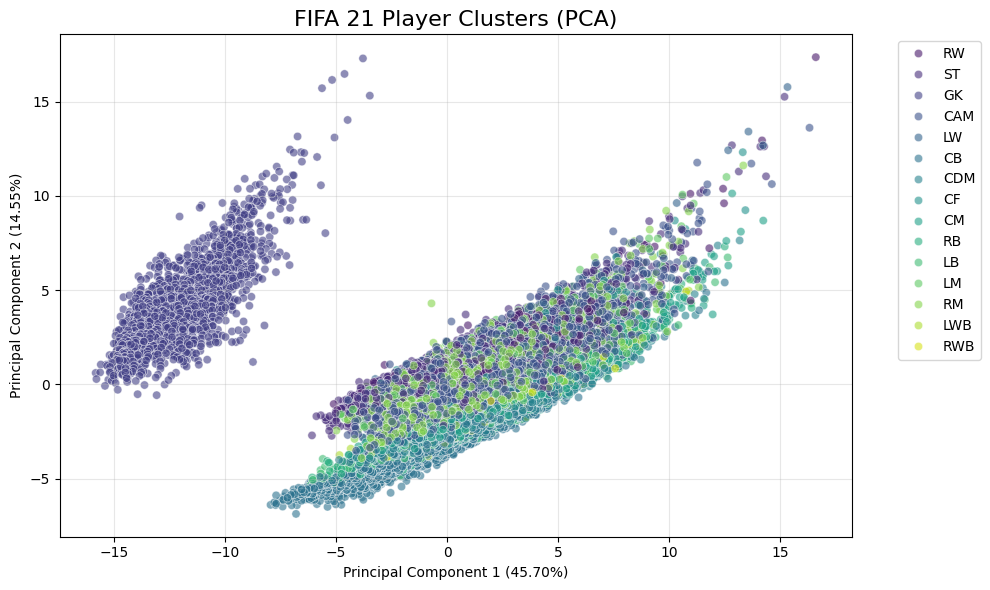

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Position',
    data=pca_df,
    alpha=0.6,
    palette='viridis'
)

plt.title('FIFA 21 Player Clusters (PCA)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({variance_ratio[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({variance_ratio[1]*100:.2f}%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
pca_3d = PCA(n_components=3)
components_3d = pca_3d.fit_transform(X_scaled)
df_3d = pd.DataFrame(components_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['Name'] = df['name']
df_3d['Position'] = df['best_position']
print(f"Total Variance in 3D: {sum(pca_3d.explained_variance_ratio_) * 100:.2f}%")
print('')
fig = px.scatter_3d(
    df_3d, x='PC1', y='PC2', z='PC3',
    color='Position',
    hover_name='Name',
    title='FIFA 21 PCA Analysis (3D Interactive)',
    opacity=0.6,
    width=800,
    height=600
)

fig.update_traces(marker=dict(size=3))

fig.show()

Total Variance in 3D: 77.72%

